# Three-Model Ensemble V2 — Full Walk-Forward Performance Evaluation

Runs all quarterly folds for each sub-model, then combines via **hard majority vote** (primary):  
each model casts {-1, 0, +1}; majority wins; ties → neutral.

Soft-prob averaging is retained as a diagnostic reference.

**V2 feature set (final)**:
- **Price** (5): `td_return_5d`, `td_return_20d`, `td_vs_xfn_5d`, `td_vs_xfn_20d`, `td_dist_52w_high_v2`
- **Transcript** (10): unchanged from V1
- **News** (5): `news_sent_mean_7d/30d`, `news_count_7d/30d`, `days_since_last_news` (back to V1 windows)


## 1. Imports, Paths & Best-Params Load

In [1]:
import sys
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from IPython.display import display

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path('').resolve()
ROOT = NOTEBOOK_DIR.parents[1]
EXP_PARENT = ROOT / 'step3_predictive_model/model_experiments_archive'
for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'

param_files = sorted(ARTIFACT_DIR.glob('best_params_*.json'))
assert param_files, 'No best_params_*.json found — run xgb_ensemble_v2_training.ipynb first'
params_path = param_files[-1]
with open(params_path) as f:
    saved = json.load(f)

TARGET            = saved['target']
THRESHOLD         = saved['threshold']
LABEL_MAP         = {-1: 0, 0: 1, 1: 2}
INV_MAP           = {0: -1, 1: 0, 2: 1}
TRAIN_WINDOW_DAYS = saved['train_window_days']
QUARTER_DAYS      = saved['quarter_days']
GAP_DAYS          = saved['gap_days']
STRIDE            = saved['stride']
ALL_FEATURES      = saved['features']
BEST_PARAMS       = saved['best_params']

print(f'Loaded params from: {params_path.name}')
for m, p in BEST_PARAMS.items():
    print(f'  [{m}] {p}')

Loaded params from: best_params_2026-04-23.json
  [price] {'max_depth': 3, 'min_child_weight': 30, 'n_estimators': 120, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist'}
  [transcript] {'max_depth': 4, 'min_child_weight': 20, 'n_estimators': 80, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist'}
  [news] {'max_depth': 2, 'min_child_weight': 30, 'n_estimators': 50, 'reg_alpha': 0.2, 'reg_lambda': 2.0, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist'}


## 2. Data Load & Feature Engineering
(Must match training notebook exactly.)

In [2]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class

df = load_dataset()

# ── td_dist_52w_high_v2 from TD raw prices ───────────────────────────────
td_raw = pd.read_parquet(ROOT / 'data/raw/prices/TD_TO.parquet')
td_raw['date'] = pd.to_datetime(td_raw['date'])
td_raw = td_raw.sort_values('date').reset_index(drop=True)
high_252 = td_raw['adj_close'].rolling(252).max()
td_raw['td_dist_52w_high_v2'] = (td_raw['adj_close'] - high_252) / td_raw['adj_close']
df = df.merge(td_raw[['date', 'td_dist_52w_high_v2']], on='date', how='left')

# ── td_vs_xfn_20d: both columns already in parquet ───────────────────────
df['td_vs_xfn_20d'] = df['td_return_20d'] - df['xfn_return_20d']

# ── Model 2 — undecayed NLP features (CEO+CFO combined, no call_decay) ───
df['exec_tone_ffill'] = df[['transcript_ceo_prep_sentiment_mean_ffill',
                             'transcript_cfo_prep_sentiment_mean_ffill']].mean(axis=1)

print(f'Loaded {len(df)} rows  |  {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Engineered: td_dist_52w_high_v2, td_vs_xfn_20d, exec_tone_ffill')


Loaded 1285 rows  |  2021-02-25 to 2026-04-09
Engineered: td_dist_52w_high_v2, td_vs_xfn_20d, exec_tone_ffill


## 3. Fold Definitions

In [3]:
def make_quarterly_rolling2y_folds(df, target,
                                   train_days=TRAIN_WINDOW_DAYS,
                                   quarter_days=QUARTER_DAYS,
                                   gap=GAP_DAYS):
    dated = df[df[target].notna()].sort_values('date')
    dates = dated['date'].values
    folds = []
    i, fold_id = train_days + gap, 1
    while i < len(dates):
        te_end_i      = min(i + quarter_days - 1, len(dates) - 1)
        train_end_idx = i - 1 - gap
        tr_s_i        = max(0, train_end_idx + 1 - train_days)
        folds.append((
            fold_id,
            str(dates[tr_s_i])[:10],
            str(dates[train_end_idx])[:10],
            str(dates[i])[:10],
            str(dates[te_end_i])[:10],
        ))
        i = te_end_i + 1
        fold_id += 1
    return folds

FOLDS = make_quarterly_rolling2y_folds(df, TARGET)
print(f'Total quarterly folds: {len(FOLDS)}')

Total quarterly folds: 13


## 4. Evaluation Helpers

In [4]:
def fit_xgb(train_df, test_df, features, params):
    """Returns (clf, hard_preds, y_cls, y_cont, prob_matrix)."""
    x_tr  = train_df[features].fillna(train_df[features].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([LABEL_MAP[v] for v in y_tr], dtype=int)

    clf = xgb.XGBClassifier(
        objective='multi:softprob', num_class=3,
        random_state=42, n_jobs=1, verbosity=0, **params
    )
    clf.fit(x_tr, y_enc)

    x_te      = test_df[features].fillna(train_df[features].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    prob_mat  = clf.predict_proba(x_te)
    hard_pred = np.array([INV_MAP[int(p)] for p in clf.predict(x_te)])
    return clf, hard_pred, y_te_cls, y_te_cont, prob_mat


def offset_metrics(preds, y_true_cls, y_true_cont, prob_matrix=None):
    """
    Stride-offset averaged metrics.
    prob_matrix (n, 3) — columns [P(-1), P(0), P(+1)] — enables directional OVR AUC.
    Neutral class excluded from AUC as it carries no trading signal.
    """
    rows = []
    for off in range(STRIDE):
        idx = np.arange(off, len(preds), STRIDE)
        p, y_cls, y_cont = preds[idx], y_true_cls[idx], y_true_cont[idx]
        active = (p != 0)
        row = {
            'directional_call_rate': active.mean(),
            'directional_accuracy':  float((np.sign(p[active]) == np.sign(y_cont[active])).mean())
                                     if active.sum() > 0 else np.nan,
        }
        if prob_matrix is not None:
            pm    = prob_matrix[idx]
            y_enc = np.array([LABEL_MAP[v] for v in y_cls], dtype=int)
            try:
                row['auc_pos'] = roc_auc_score((y_enc == 2).astype(int), pm[:, 2])
            except Exception:
                row['auc_pos'] = np.nan
            try:
                row['auc_neg'] = roc_auc_score((y_enc == 0).astype(int), pm[:, 0])
            except Exception:
                row['auc_neg'] = np.nan
        rows.append(row)
    return pd.DataFrame(rows).mean()


def softprob_to_hard(prob_mat):
    return np.array([INV_MAP[int(p)] for p in prob_mat.argmax(axis=1)])


def hard_majority_vote(preds_list):
    stack  = np.vstack(preds_list).T
    result = np.zeros(len(stack), dtype=int)
    for i, row in enumerate(stack):
        counts  = {v: (row == v).sum() for v in [-1, 0, 1]}
        max_c   = max(counts.values())
        winners = [v for v, c in counts.items() if c == max_c]
        result[i] = 0 if len(winners) > 1 else winners[0]
    return result


print('Helpers defined.')

Helpers defined.


## 5. Full Walk-Forward: Individual Models

In [5]:
model_names = list(ALL_FEATURES.keys())

fold_hard_preds  = {m: [] for m in model_names}
fold_prob_mats   = {m: [] for m in model_names}
fold_y_cls_list  = []
fold_y_cont_list = []
fold_clfs        = {m: [] for m in model_names}
fold_x_te_list   = {m: [] for m in model_names}
indiv_results    = {m: [] for m in model_names}

print('Running full walk-forward on all folds...')
for fold_id, tr_s, tr_e, te_s, te_e in FOLDS:
    train_df = df[(df['date'] >= pd.Timestamp(tr_s)) &
                  (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
    test_df  = df[(df['date'] >= pd.Timestamp(te_s)) &
                  (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    if len(test_df) < 5:
        continue

    y_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_cont = test_df[TARGET].values
    fold_y_cls_list.append(y_cls)
    fold_y_cont_list.append(y_cont)

    for model_name in model_names:
        features = ALL_FEATURES[model_name]
        params   = BEST_PARAMS[model_name]
        clf, hard_pred, _, _, prob_mat = fit_xgb(train_df, test_df, features, params)

        fold_hard_preds[model_name].append(hard_pred)
        fold_prob_mats[model_name].append(prob_mat)
        fold_clfs[model_name].append(clf)
        fold_x_te_list[model_name].append(
            test_df[features].fillna(train_df[features].median()).reset_index(drop=True)
        )

        m = offset_metrics(hard_pred, y_cls, y_cont, prob_matrix=prob_mat)
        indiv_results[model_name].append({
            'fold': fold_id, 'train_rows': len(train_df), 'test_rows': len(test_df),
            'train_start': tr_s, 'train_end': tr_e,
            'test_start': te_s, 'test_end': te_e, **m.to_dict()
        })

    print(f'Fold {fold_id:>2}  [{te_s} → {te_e}]  n_test={len(test_df)}')

print(f'\nDone. {len(fold_y_cls_list)} folds evaluated.')

Running full walk-forward on all folds...
Fold  1  [2023-03-08 → 2023-06-06]  n_test=63
Fold  2  [2023-06-07 → 2023-09-06]  n_test=63


Fold  3  [2023-09-07 → 2023-12-05]  n_test=63
Fold  4  [2023-12-06 → 2024-03-07]  n_test=63
Fold  5  [2024-03-08 → 2024-06-06]  n_test=63
Fold  6  [2024-06-07 → 2024-09-06]  n_test=63


Fold  7  [2024-09-09 → 2024-12-05]  n_test=63
Fold  8  [2024-12-06 → 2025-03-10]  n_test=63
Fold  9  [2025-03-11 → 2025-06-09]  n_test=63
Fold 10  [2025-06-10 → 2025-09-09]  n_test=63


Fold 11  [2025-09-10 → 2025-12-08]  n_test=63
Fold 12  [2025-12-09 → 2026-03-11]  n_test=63
Fold 13  [2026-03-12 → 2026-04-09]  n_test=20

Done. 13 folds evaluated.


## 6. Ensemble Predictions

**Primary**: Hard majority vote.  
**Diagnostic**: Soft-prob average.

In [6]:
ensemble_results_soft = []
ensemble_results_hard = []

for fi, (fold_id, tr_s, tr_e, te_s, te_e) in enumerate(FOLDS):
    if fi >= len(fold_y_cls_list):
        break
    y_cls  = fold_y_cls_list[fi]
    y_cont = fold_y_cont_list[fi]

    # Soft-prob average
    probs    = [fold_prob_mats[m][fi] for m in model_names]
    avg_prob = np.mean(np.stack(probs, axis=0), axis=0)
    soft_pred = softprob_to_hard(avg_prob)
    m_soft = offset_metrics(soft_pred, y_cls, y_cont, prob_matrix=avg_prob)
    ensemble_results_soft.append({
        'fold': fold_id, 'test_rows': len(y_cls),
        'test_start': te_s, 'test_end': te_e, **m_soft.to_dict()
    })

    # Hard majority vote
    hards   = [fold_hard_preds[m][fi] for m in model_names]
    mv_pred = hard_majority_vote(hards)
    m_hard  = offset_metrics(mv_pred, y_cls, y_cont)
    ensemble_results_hard.append({
        'fold': fold_id, 'test_rows': len(y_cls),
        'test_start': te_s, 'test_end': te_e, **m_hard.to_dict()
    })

df_soft = pd.DataFrame(ensemble_results_soft).set_index('fold')
df_hard = pd.DataFrame(ensemble_results_hard).set_index('fold')
print('Ensemble predictions assembled.')

Ensemble predictions assembled.


## 7. Performance Summary

In [7]:
display_cols = ['test_rows', 'directional_call_rate', 'directional_accuracy', 'auc_pos', 'auc_neg']

def print_aggregate(df_res, label):
    metric_cols = [c for c in display_cols[1:] if c in df_res.columns]
    means = df_res[metric_cols].mean()
    print(f'=== {label} — Aggregate ===')
    print(f'  Directional call rate : {means["directional_call_rate"]:.3f}  (share of days with ±1)')
    print(f'  Directional accuracy  : {means["directional_accuracy"]:.3f}  (correct sign on active calls; random=0.50)')
    if 'auc_pos' in means:
        print(f'  AUC (+1 class)        : {means["auc_pos"]:.3f}  (prob-based, diagnostic only)')
    if 'auc_neg' in means:
        print(f'  AUC (-1 class)        : {means["auc_neg"]:.3f}  (prob-based, diagnostic only)')
    return means

# Hard majority vote — primary
print('=== Ensemble (Hard Majority Vote) — Per-Fold ===')
display(df_hard[[c for c in display_cols if c in df_hard.columns]].round(3))
means_hard = print_aggregate(df_hard, 'Hard Majority Vote')

print()

# Soft-prob — diagnostic
print('=== Ensemble (Soft-Prob Average) — Per-Fold ===')
display(df_soft[[c for c in display_cols if c in df_soft.columns]].round(3))
means_soft = print_aggregate(df_soft, 'Soft-Prob Ensemble')

print()

# Individual models
for model_name in model_names:
    df_indiv = pd.DataFrame(indiv_results[model_name]).set_index('fold')
    print(f'=== Individual: {model_name} — Per-Fold ===')
    display(df_indiv[[c for c in display_cols if c in df_indiv.columns]].round(3))
    print_aggregate(df_indiv, f'Individual — {model_name}')
    print()

=== Ensemble (Hard Majority Vote) — Per-Fold ===


,test_rows,directional_call_rate,directional_accuracy
fold,,,
1,63,0.968,0.361
2,63,0.951,0.694
3,63,1.000,0.538
4,63,0.968,0.657
5,63,1.000,0.572
6,63,0.936,0.594
7,63,1.000,0.686
8,63,0.985,0.388
9,63,1.000,0.459


=== Hard Majority Vote — Aggregate ===
  Directional call rate : 0.982  (share of days with ±1)
  Directional accuracy  : 0.566  (correct sign on active calls; random=0.50)

=== Ensemble (Soft-Prob Average) — Per-Fold ===


,test_rows,directional_call_rate,directional_accuracy,auc_pos,auc_neg
fold,,,,,
1,63,1.0,0.319,0.314,0.277
2,63,1.0,0.651,0.786,0.790
3,63,1.0,0.601,0.604,0.557
4,63,1.0,0.588,0.558,0.533
5,63,1.0,0.540,0.714,0.497
6,63,1.0,0.573,0.543,0.704
7,63,1.0,0.590,0.566,0.592
8,63,1.0,0.273,0.682,0.637
9,63,1.0,0.459,0.381,0.212


=== Soft-Prob Ensemble — Aggregate ===
  Directional call rate : 1.000  (share of days with ±1)
  Directional accuracy  : 0.536  (correct sign on active calls; random=0.50)
  AUC (+1 class)        : 0.561  (prob-based, diagnostic only)
  AUC (-1 class)        : 0.591  (prob-based, diagnostic only)

=== Individual: price — Per-Fold ===


...

=== Individual — price — Aggregate ===
  Directional call rate : 0.972  (share of days with ±1)
  Directional accuracy  : 0.530  (correct sign on active calls; random=0.50)
  AUC (+1 class)        : 0.508  (prob-based, diagnostic only)
  AUC (-1 class)        : 0.530  (prob-based, diagnostic only)

=== Individual: transcript — Per-Fold ===


,test_rows,directional_call_rate,directional_accuracy,auc_pos,auc_neg
fold,,,,,
1,63,1.000,0.477,0.506,0.545
2,63,1.000,0.491,0.586,0.683
3,63,1.000,0.588,0.555,0.542
4,63,1.000,0.556,0.265,0.489
5,63,1.000,0.637,0.789,0.811
6,63,0.921,0.573,0.649,0.740
7,63,1.000,0.699,0.647,0.569
8,63,1.000,0.273,0.476,0.397
9,63,0.985,0.304,0.363,0.361


=== Individual — transcript — Aggregate ===
  Directional call rate : 0.993  (share of days with ±1)
  Directional accuracy  : 0.550  (correct sign on active calls; random=0.50)
  AUC (+1 class)        : 0.547  (prob-based, diagnostic only)
  AUC (-1 class)        : 0.608  (prob-based, diagnostic only)

=== Individual: news — Per-Fold ===


,test_rows,directional_call_rate,directional_accuracy,auc_pos,auc_neg
fold,,,,,
1,63,1.000,0.477,0.492,0.374
2,63,1.000,0.760,0.711,0.637
3,63,1.000,0.472,0.653,0.677
4,63,1.000,0.524,0.607,0.551
5,63,1.000,0.523,0.571,0.432
6,63,1.000,0.536,0.496,0.516
7,63,1.000,0.542,0.378,0.456
8,63,1.000,0.509,0.590,0.660
9,63,1.000,0.636,0.646,0.553


=== Individual — news — Aggregate ===
  Directional call rate : 0.996  (share of days with ±1)
  Directional accuracy  : 0.536  (correct sign on active calls; random=0.50)
  AUC (+1 class)        : 0.564  (prob-based, diagnostic only)
  AUC (-1 class)        : 0.557  (prob-based, diagnostic only)



## 7b. Per-Fold Confusion Matrix — Hard Majority Vote

Actual vs predicted class counts for each fold. Classes: **−1** (underperform), **0** (neutral), **+1** (outperform).

In [8]:
from sklearn.metrics import confusion_matrix

print(f"{'Fold':<6} {'Period':<24}  {'DA':>5}  Confusion Matrix (rows=Actual, cols=Predicted)")
print(f"{'':6} {'':24}  {'':5}  {'':6}  pred -1   pred  0   pred +1")
print('-' * 75)

for fi, (fold_id, tr_s, tr_e, te_s, te_e) in enumerate(FOLDS):
    if fi >= len(fold_y_cls_list):
        break
    y_cls  = fold_y_cls_list[fi]     # encoded: 0=-1, 1=0, 2=+1
    y_cont = fold_y_cont_list[fi]

    hards  = [fold_hard_preds[m][fi] for m in model_names]
    mv_pred = hard_majority_vote(hards)  # encoded predictions

    cm = confusion_matrix(y_cls, mv_pred, labels=[0, 1, 2])
    active = mv_pred != 1
    da = float((np.sign(INV_MAP[p] if isinstance(p,int) else p) == np.sign(y_cont))[active].mean()) if active.any() else float('nan')

    # map encoded predictions back to -1/0/+1 labels
    mv_decoded = np.array([INV_MAP[p] for p in mv_pred])
    y_decoded  = np.array([INV_MAP[p] for p in y_cls])
    cm2 = confusion_matrix(y_decoded, mv_decoded, labels=[-1, 0, 1])

    period = f'{te_s} → {te_e}'
    # count actual class distribution
    neg_act = (y_decoded == -1).sum()
    neu_act = (y_decoded ==  0).sum()
    pos_act = (y_decoded ==  1).sum()
    # count predicted class distribution
    neg_pred = (mv_decoded == -1).sum()
    neu_pred = (mv_decoded ==  0).sum()
    pos_pred = (mv_decoded ==  1).sum()

    da_ens = df_hard.loc[fold_id, 'directional_accuracy'] if fold_id in df_hard.index else float('nan')

    print(f"{fold_id:<6} {period:<24}  {da_ens:>5.3f}  actual: -1={neg_act:>2} 0={neu_act:>2} +1={pos_act:>2}  |  predicted: -1={neg_pred:>2} 0={neu_pred:>2} +1={pos_pred:>2}")
    print(f"{'':6} {'':24}  {'':5}  Confusion (actual↓ pred→):  pred-1  pred0  pred+1")
    for actual_cls, row in zip([-1, 0, 1], cm2):
        print(f"{'':6} {'':24}  {'':5}    actual {actual_cls:>+2}:          {row[0]:>5}  {row[1]:>5}  {row[2]:>5}")
    print()

Fold  1  2023-03-08 → 2023-06-06   DA=0.361
  Actual distribution:    -1=28  0= 8  +1=27
  Predicted distribution: -1=16  0= 2  +1=45
  Confusion matrix (rows=actual, cols=predicted):
              pred -1  pred  0  pred +1
  actual -1:       5        1       22
  actual  0:       3        0        5
  actual +1:       8        1       18

Fold  2  2023-06-07 → 2023-09-06   DA=0.694
  Actual distribution:    -1=16  0=10  +1=37
  Predicted distribution: -1=35  0= 0  +1=28
  Confusion matrix (rows=actual, cols=predicted):
              pred -1  pred  0  pred +1
  actual -1:      15        0        1
  actual  0:       7        0        3
  actual +1:      13        0       24

Fold  3  2023-09-07 → 2023-12-05   DA=0.538
  Actual distribution:    -1=24  0=15  +1=24
  Predicted distribution: -1=36  0= 0  +1=27
  Confusion matrix (rows=actual, cols=predicted):
              pred -1  pred  0  pred +1
  actual -1:      14        0       10
  actual  0:      11        0        4
  actual +1:  

## 8. SHAP — Out-of-Sample Test Data (+1 and −1)

Pools all walk-forward **test rows** (each scored by the model trained on data before that quarter).  
Beeswarms for **class +1** (encoded index 2) and **class −1** (encoded index 0); neutral omitted.

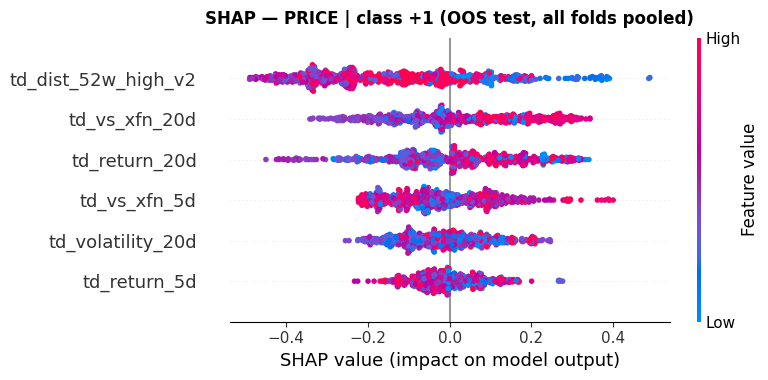

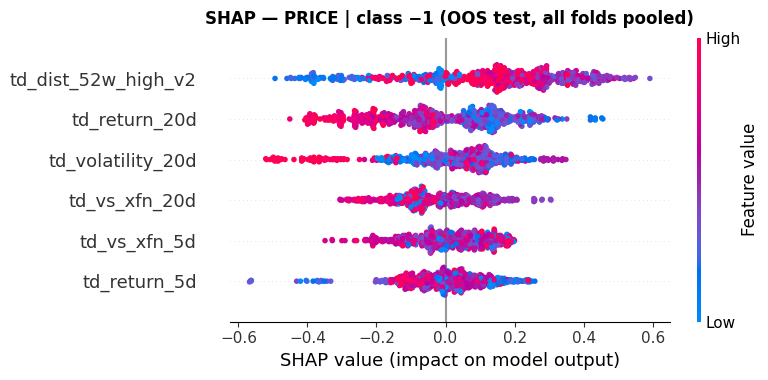

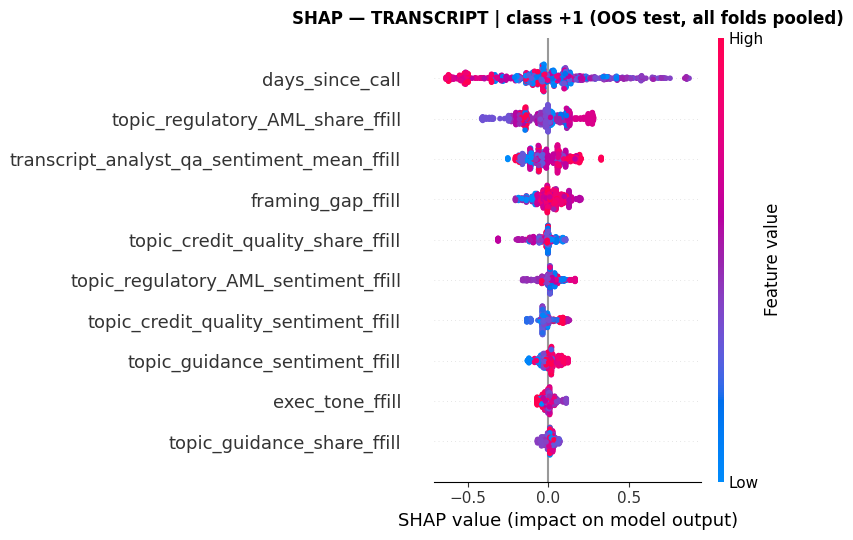

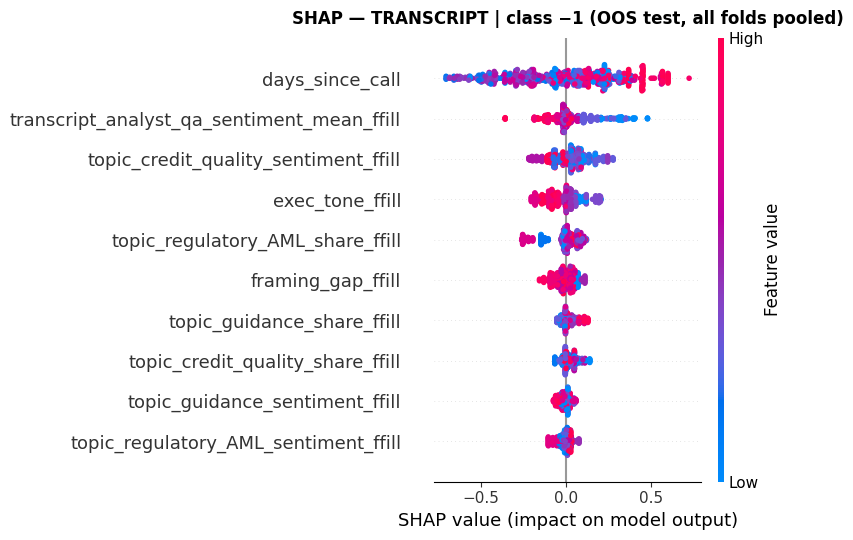

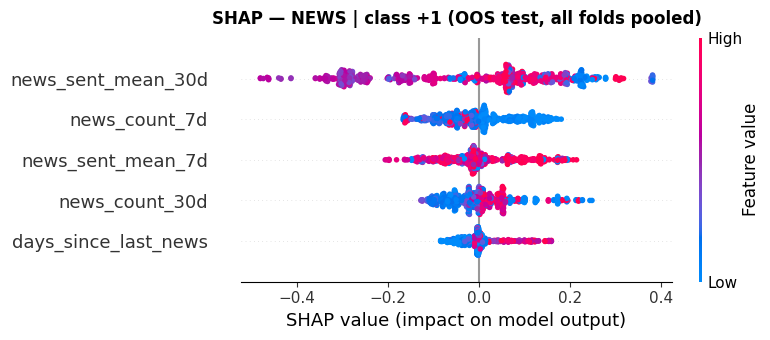

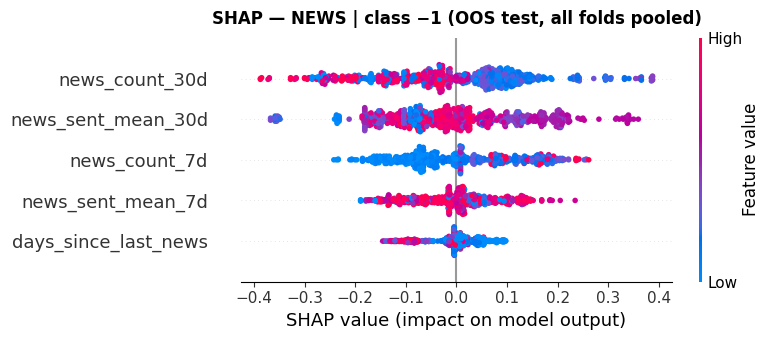

In [8]:
for model_name in model_names:
    features = ALL_FEATURES[model_name]
    x_parts, sv_up_parts, sv_dn_parts = [], [], []

    for fi, clf in enumerate(fold_clfs[model_name]):
        x_te = fold_x_te_list[model_name][fi]
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(x_te)
        if isinstance(sv, list):
            sv_up = sv[2]
            sv_dn = sv[0]
        else:
            sv_arr = np.asarray(sv)
            sv_up = sv_arr[:, :, 2] if sv_arr.ndim == 3 else sv_arr
            sv_dn = sv_arr[:, :, 0] if sv_arr.ndim == 3 else sv_arr

        x_parts.append(x_te)
        sv_up_parts.append(sv_up)
        sv_dn_parts.append(sv_dn)

    x_all = pd.concat(x_parts, ignore_index=True)
    sv_up = np.vstack(sv_up_parts)
    sv_dn = np.vstack(sv_dn_parts)

    fig_h = max(4.5, len(features) * 0.42)
    plt.figure(figsize=(8, fig_h))
    shap.summary_plot(sv_up, x_all, plot_type='dot', show=False, max_display=len(features))
    plt.title(f'SHAP — {model_name.upper()} | class +1 (OOS test, all folds pooled)',
              fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, fig_h))
    shap.summary_plot(sv_dn, x_all, plot_type='dot', show=False, max_display=len(features))
    plt.title(f'SHAP — {model_name.upper()} | class −1 (OOS test, all folds pooled)',
              fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

## 9. Walk-Forward SHAP Importance (Mean |SHAP| per Fold)

Per-fold test SHAP averaged across folds — side-by-side bars for +1 (steelblue) and −1 (tomato).

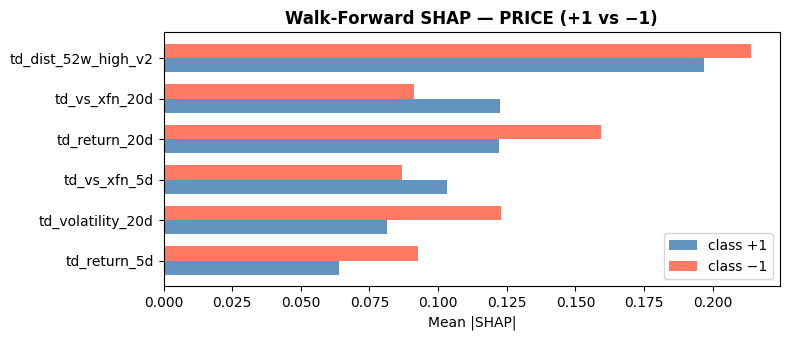


[price] Mean |SHAP| (+1):


,mean_abs_shap_+1
td_dist_52w_high_v2,0.1969
td_vs_xfn_20d,0.1226
td_return_20d,0.1221
td_vs_xfn_5d,0.1033
td_volatility_20d,0.0813
td_return_5d,0.0638


[price] Mean |SHAP| (−1):


,mean_abs_shap_-1
td_dist_52w_high_v2,0.2138
td_return_20d,0.1594
td_volatility_20d,0.1229
td_return_5d,0.0928
td_vs_xfn_20d,0.0913
td_vs_xfn_5d,0.0867


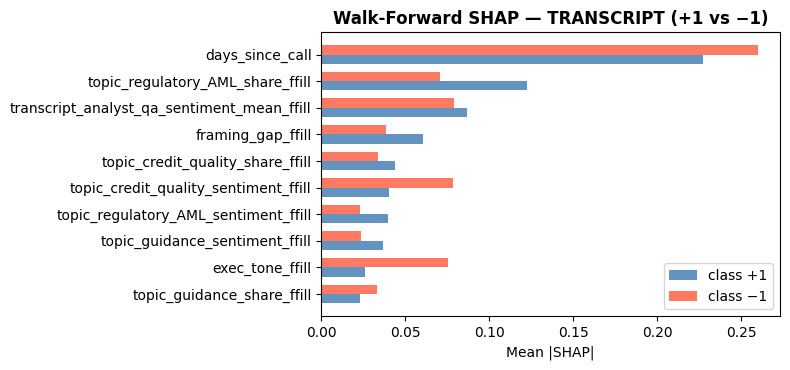


[transcript] Mean |SHAP| (+1):


,mean_abs_shap_+1
days_since_call,0.2270
topic_regulatory_AML_share_ffill,0.1226
transcript_analyst_qa_sentiment_mean_ffill,0.0866
framing_gap_ffill,0.0604
topic_credit_quality_share_ffill,0.0436
topic_credit_quality_sentiment_ffill,0.0402
topic_regulatory_AML_sentiment_ffill,0.0398
topic_guidance_sentiment_ffill,0.0367
exec_tone_ffill,0.0261
topic_guidance_share_ffill,0.0228


[transcript] Mean |SHAP| (−1):


,mean_abs_shap_-1
days_since_call,0.2601
transcript_analyst_qa_sentiment_mean_ffill,0.0788
topic_credit_quality_sentiment_ffill,0.0784
exec_tone_ffill,0.0753
topic_regulatory_AML_share_ffill,0.0709
framing_gap_ffill,0.0384
topic_credit_quality_share_ffill,0.0338
topic_guidance_share_ffill,0.0331
topic_guidance_sentiment_ffill,0.0233
topic_regulatory_AML_sentiment_ffill,0.0230


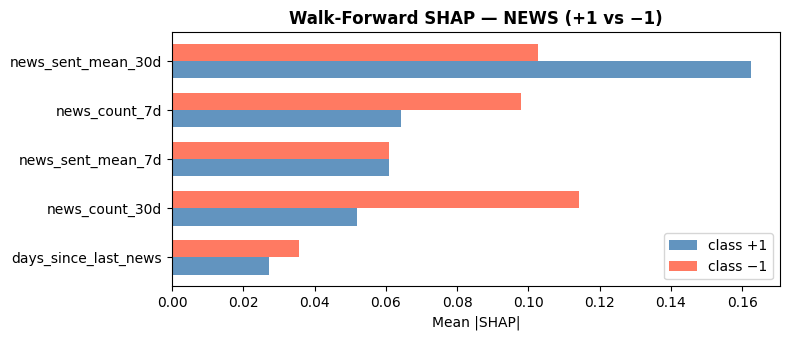


[news] Mean |SHAP| (+1):


,mean_abs_shap_+1
news_sent_mean_30d,0.1625
news_count_7d,0.0642
news_sent_mean_7d,0.0607
news_count_30d,0.0520
days_since_last_news,0.0273


[news] Mean |SHAP| (−1):


,mean_abs_shap_-1
news_count_30d,0.1140
news_sent_mean_30d,0.1028
news_count_7d,0.0979
news_sent_mean_7d,0.0609
days_since_last_news,0.0356


In [9]:
for model_name in model_names:
    features = ALL_FEATURES[model_name]
    rows_up, rows_dn = [], []

    for fi, clf in enumerate(fold_clfs[model_name]):
        x_te = fold_x_te_list[model_name][fi]
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(x_te)
        if isinstance(sv, list):
            sv_up = sv[2]
            sv_dn = sv[0]
        else:
            sv_arr = np.asarray(sv)
            sv_up = sv_arr[:, :, 2] if sv_arr.ndim == 3 else sv_arr
            sv_dn = sv_arr[:, :, 0] if sv_arr.ndim == 3 else sv_arr

        rows_up.append(pd.Series(np.abs(sv_up).mean(axis=0), index=features))
        rows_dn.append(pd.Series(np.abs(sv_dn).mean(axis=0), index=features))

    mean_up = pd.DataFrame(rows_up).mean().sort_values(ascending=True)
    mean_dn = pd.DataFrame(rows_dn).mean().reindex(mean_up.index)

    y_pos = np.arange(len(mean_up))
    h = 0.35
    plt.figure(figsize=(8, max(3.5, len(features) * 0.38)))
    plt.barh(y_pos - h / 2, mean_up.values, height=h, label='class +1', color='steelblue', alpha=0.85)
    plt.barh(y_pos + h / 2, mean_dn.values, height=h, label='class −1', color='tomato', alpha=0.85)
    plt.yticks(y_pos, mean_up.index)
    plt.xlabel('Mean |SHAP|')
    plt.title(f'Walk-Forward SHAP — {model_name.upper()} (+1 vs −1)', fontweight='bold')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    print(f'\n[{model_name}] Mean |SHAP| (+1):')
    display(mean_up.sort_values(ascending=False).round(4).to_frame('mean_abs_shap_+1'))
    print(f'[{model_name}] Mean |SHAP| (−1):')
    display(mean_dn.sort_values(ascending=False).round(4).to_frame('mean_abs_shap_-1'))

## 10. Per-Fold SHAP Breakdown — All Models

Top-3 features by mean |SHAP| for each model, each fold, for class +1 and class −1.
Useful for understanding which signals drove (or misled) predictions in each specific quarter.

In [10]:
fold_da_map = {r['fold']: r['directional_accuracy'] for r in df_hard.reset_index().to_dict('records')}

for model_name in model_names:
    features = ALL_FEATURES[model_name]
    print(f'\n{'='*70}')
    print(f'MODEL: {model_name.upper()}')
    print(f'{'='*70}')
    print(f'{"Fold":<6} {"Period":<24} {"DA":>5}  Top-3 +1                           Top-3 -1')
    print('-'*110)

    for fi, (fold_id, tr_s, tr_e, te_s, te_e) in enumerate(FOLDS):
        if fi >= len(fold_clfs[model_name]):
            break
        clf = fold_clfs[model_name][fi]
        x_te = fold_x_te_list[model_name][fi]

        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(x_te)
        if isinstance(sv, list):
            sv_up = np.abs(sv[2]).mean(axis=0)
            sv_dn = np.abs(sv[0]).mean(axis=0)
        else:
            sv_arr = np.asarray(sv)
            sv_up = np.abs(sv_arr[:, :, 2]).mean(axis=0)
            sv_dn = np.abs(sv_arr[:, :, 0]).mean(axis=0)

        top3_up = [(features[j], round(float(sv_up[j]), 3)) for j in np.argsort(sv_up)[::-1][:3]]
        top3_dn = [(features[j], round(float(sv_dn[j]), 3)) for j in np.argsort(sv_dn)[::-1][:3]]

        period = f'{te_s} → {te_e}'
        da = fold_da_map.get(fold_id, float('nan'))
        up_str = ', '.join(f'{f}({v})' for f, v in top3_up)
        dn_str = ', '.join(f'{f}({v})' for f, v in top3_dn)
        print(f'{fold_id:<6} {period:<24} {da:>5.3f}  {up_str}')
        print(f'{"":<6} {"":<24} {"":<5}  → {dn_str}')
        print()


Fold  1  [2023-03-08 → 2023-06-06]  Ensemble DA=0.361
  Model        Class  Top-3 Features (mean |SHAP|)
  --------------------------------------------------------------------------------
  price        +1     td_return_20d (0.183)  |  td_dist_52w_high_v2 (0.135)  |  td_vs_xfn_20d (0.104)
               -1     td_vs_xfn_5d (0.139)  |  td_vs_xfn_20d (0.102)  |  td_volatility_20d (0.100)
  transcript   +1     topic_credit_quality_share_ffill (0.105)  |  topic_regulatory_AML_share_ffill (0.102)  |  days_since_call (0.098)
               -1     days_since_call (0.187)  |  topic_regulatory_AML_share_ffill (0.173)  |  framing_gap_ffill (0.082)
  news         +1     news_sent_mean_30d (0.077)  |  news_sent_mean_7d (0.057)  |  news_count_30d (0.036)
               -1     news_count_30d (0.205)  |  news_sent_mean_30d (0.107)  |  news_sent_mean_7d (0.034)

Fold  2  [2023-06-07 → 2023-09-06]  Ensemble DA=0.694
  Model        Class  Top-3 Features (mean |SHAP|)
  ---------------------------------